# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

## Setup and Configuration

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import shutil
import os

import subprocess

from tqdm import tqdm
import json

import io
import re
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

## Step 1: Download Matplotlib Examples

Download matplotlib examples repository using sparse checkout to get only the galleries/examples directory.

In [3]:

# Check if matplotlib repo already exists
if not Path("matplotlib").exists():
    print("Downloading matplotlib examples repository...")
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/matplotlib/matplotlib.git
    %cd matplotlib
    !git sparse-checkout init --cone
    !git sparse-checkout set galleries/examples
    %cd ..
    print("Download complete.")
else:
    print("Matplotlib repository already exists. Skipping download.")

Matplotlib repository already exists. Skipping download.


## Step 2: Filter Example Categories

Keep only specific plot categories and remove others to focus on relevant plot types.

In [4]:
# Define the root directory and categories to keep
root = Path("matplotlib/galleries/examples")
keep = [
    "lines_bars_and_markers",
    "statistics",
    "pie_and_polar_charts",
    "mplot3d"
]

# Remove all directories except the ones we want to keep
for p in root.iterdir():
    if p.is_dir() and p.name not in keep:
        shutil.rmtree(p)
        print(f"Deleted: {p}")

## Step 3: Generate Dataset

Execute matplotlib example scripts and save the resulting plots with their source code.

In [5]:


# Check if dataset already exists
dataset_file = Path("plot2code_exec.jsonl")
if dataset_file.exists():
    print(f"Dataset file '{dataset_file}' already exists. Skipping generation.")
    print(f"Delete the file if you want to regenerate the dataset.")
else:
    # Setup directories and paths
    root = Path("matplotlib/galleries/examples")
    gallery_dir = Path("plot_gallery_exec")
    gallery_dir.mkdir(exist_ok=True)
    
    dataset = []
    examples = list(root.rglob("*.py"))
    
    # Process each example script (limited to 100 for demo)
    for f in tqdm(examples[:100], desc="Generating plots"):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = open(f).read()
            # Run safely in isolated process using non-interactive backend
            cmd = f"""
import matplotlib; matplotlib.use('Agg');
import matplotlib.pyplot as plt;
exec(open(r'{f}').read());
plt.savefig(r'{out_png}');
"""
            subprocess.run(["python", "-c", cmd], check=True, timeout=20)
            dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            # Skip examples that fail to execute
            pass
    
    # Save dataset to JSONL file
    print(f"Generated {len(dataset)} plots")
    with open(dataset_file, "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")
    print(f"Dataset saved to {dataset_file}")

Dataset file 'plot2code_exec.jsonl' already exists. Skipping generation.
Delete the file if you want to regenerate the dataset.


## Step 4: Preview Dataset

Load and display random samples from the generated dataset.

Loaded 95 samples


### `multivariate_marker_plot.png`

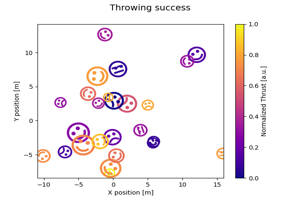

```python
"""
==============================================
Mapping marker properties to multivariate data
==============================================

This example shows how to use different properties of markers to plot
multivariate datasets. Here we represent a successful baseball throw as a
smiley face with marker size mapped to the skill of thrower, marker rotation to
the take-off angle, and thrust...
```

### `stem_plot.png`

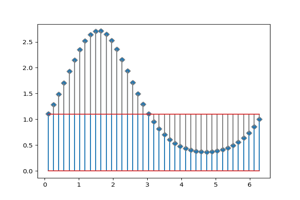

```python
"""
=========
Stem plot
=========

`~.pyplot.stem` plots vertical lines from a baseline to the y-coordinate and
places a marker at the tip.
"""
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.1, 2 * np.pi, 41)
y = np.exp(np.sin(x))

plt.stem(x, y)
plt.show()

# %%
#
# The position of the baseline can be adapted using *bottom*.
# The parameters *linefmt*, *markerfmt*, and *bas...
```

### `bar_colors.png`

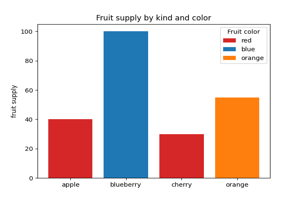

```python
"""
====================================
Bar chart with individual bar colors
====================================

This is an example showing how to control bar color and legend entries
using the *color* and *label* parameters of `~matplotlib.pyplot.bar`.
Note that labels with a preceding underscore won't show up in the legend.
"""

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fruit...
```

### `errorbar3d.png`

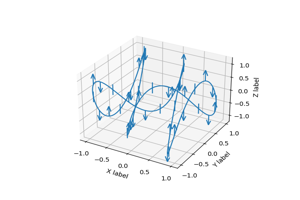

```python
"""
============
3D errorbars
============

An example of using errorbars with upper and lower limits in mplot3d.
"""

import matplotlib.pyplot as plt
import numpy as np

ax = plt.figure().add_subplot(projection='3d')

# setting up a parametric curve
t = np.arange(0, 2*np.pi+.1, 0.01)
x, y, z = np.sin(t), np.cos(3*t), np.sin(5*t)

estep = 15
i = np.arange(t.size)
zuplims = (i % estep == 0) & (i //...
```

### `gradient_bar.png`

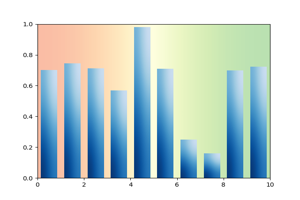

```python
"""
========================
Bar chart with gradients
========================

Matplotlib does not natively support gradients. However, we can emulate a
gradient-filled rectangle by an `.AxesImage` of the right size and coloring.

In particular, we use a colormap to generate the actual colors. It is then
sufficient to define the underlying values on the corners of the image and
let bicubic interp...
```

In [6]:
import json
import random
from PIL import Image
from IPython.display import display, Markdown

# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [7]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# Model configuration
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load processor and model
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",  # Important on CUDA 12.4
)

# Set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  1.93it/s]


## Step 6: Define Code Generation Function

Create a function to generate matplotlib code from plot images.

In [8]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=512, temperature=0.0):
    """
    Generate matplotlib code from a plot image using the VLM.
    
    Args:
        img_path: Path to the input image
        max_new_tokens: Maximum number of tokens to generate
        temperature: Sampling temperature (0.0 for deterministic)
    
    Returns:
        Generated code as a string
    """
    img = Image.open(img_path).convert("RGB")

    # Construct the prompt message
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # Apply chat template to create string with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Process text and image together
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    # Generate code
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]

## Step 7: Test Code Generation

Test the code generation on a single example image.

In [9]:
# Demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, s)

# Add title and labels
plt.title('About as simple as it gets, folks')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

# Display the plot
plt.show()
```


## Step 8: Define Evaluation Functions

Helper functions for extracting code, executing it, and computing similarity metrics.

In [10]:
# Helper functions

def extract_code(text):
    """Extract fenced Python block from LLM output."""
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    if m:
        print("Extracted fenced Python code block.")
        return m.group(1).strip()
    else:
        print("No fenced code block found; using raw text.")
        return text.strip()

def render_code_to_png(py_code, out_path):
    """Safely execute matplotlib code and save to file."""
    import builtins
    safe_builtins = {
        "range": range,
        "len": len,
        "print": print,
        "__import__": builtins.__import__,
    }

    safe_globals = {
        "__builtins__": safe_builtins,
        "np": __import__("numpy"),
        "plt": plt,
    }

    plt.close("all")
    try:
        print("Executing generated code...")
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            print("No figure created by code - creating empty figure.")
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        print(f"Saved recreated plot -> {out_path}")
        return True
    except Exception as e:
        print(f"Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    """Compute SSIM between two images (grayscale)."""
    print("Computing SSIM...")
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    score = float(ssim(a, b))
    print(f"SSIM score: {score:.4f}")
    return score

def show_side_by_side(ref_path, gen_path, score):
    """Display reference + generated + SSIM score."""
    ref = Image.open(ref_path).resize((400, 300))
    gen = Image.open(gen_path).resize((400, 300))
    combined = Image.new("RGB", (800, 300))
    combined.paste(ref, (0, 0))
    combined.paste(gen, (400, 0))
    display(Markdown(f"**SSIM:** `{score:.3f}`"))
    display(combined)

# Evaluation for one image

def evaluate_plot2code(img_path):
    """Complete evaluation pipeline for a single plot image."""
    print(f"\nEvaluating {img_path}...")

    # Generate code from model
    print("Querying model...")
    result_text = gen_code_for_image(img_path)
    print("\nModel output:\n" + "-"*60)
    print(result_text[:1000] + ("\n..." if len(result_text) > 1000 else ""))
    print("-"*60)

    # Extract code
    code = extract_code(result_text)
    print("\nExtracted code:\n" + "-"*60)
    print(code[:500] + ("\n..." if len(code) > 500 else ""))
    print("-"*60)

    # Execute and render
    gen_path = "recreated.png"
    if render_code_to_png(code, gen_path):
        # Evaluate
        score = image_ssim(img_path, gen_path)
        display(Markdown(f"### {img_path}"))
        show_side_by_side(img_path, gen_path, score)
    else:
        print("Skipping SSIM - code execution failed.")

## Step 9: Run Evaluation

Evaluate the model on a sample plot.


Evaluating plot_gallery_exec/simple_plot.png...
Querying model...

Model output:
------------------------------------------------------------
system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, s)

# Add title and labels
plt.title('About as simple as it gets, folks')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

# Display the plot
plt.show()
```
------------------------------------------------------------
Extracted fenced Python code block.

Extracted code:
------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)


### plot_gallery_exec/simple_plot.png

**SSIM:** `0.628`

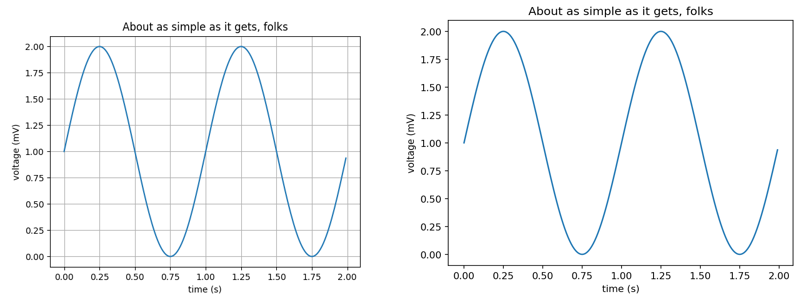

In [11]:
evaluate_plot2code("plot_gallery_exec/simple_plot.png")

## TODO List

Future improvements and tasks:

1. Clean up notebook - if dataset exists, skip generation steps
2. Remove Unicode characters
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics - exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model